In [4]:
import xarray as xr
from pathlib import Path


In [13]:

data_path = Path(r"C:\Users\Syed Haque\Documents\GitHub\ohw26_model_downsampling\data\ohw26_model_downsampling_data")
file_name = "stmb_fvcom_2017_05-06.nc"

full_path = data_path / file_name

fvcom_ds = xr.open_dataset(full_path, decode_times= False)

In [14]:
fvcom_ds

<xarray.Dataset> Size: 5GB
Dimensions:             (nele: 31697, node: 17790, siglev: 21, siglay: 20,
                         three: 3, time: 337, maxnode: 10, maxelem: 8, four: 4)
Coordinates:
    lonc                (nele) float32 127kB ...
    latc                (nele) float32 127kB ...
    lon                 (node) float32 71kB ...
    lat                 (node) float32 71kB ...
    siglev              (siglev, node) float32 1MB ...
    siglay              (siglay, node) float32 1MB ...
  * time                (time) float64 3kB 5.787e+04 5.787e+04 ... 5.789e+04
Dimensions without coordinates: nele, node, three, maxnode, maxelem, four
Data variables: (12/48)
    nprocs              int32 4B ...
    partition           (nele) int32 127kB ...
    x                   (node) float32 71kB ...
    y                   (node) float32 71kB ...
    xc                  (nele) float32 127kB ...
    yc                  (nele) float32 127kB ...
    ...                  ...
    vwind_stress        (time, nele) float32 43MB ...
    wet_nodes           (time, node) int32 24MB ...
    wet_cells           (time, nele) int32 43MB ...
    wet_nodes_prev_int  (time, node) int32 24MB ...
    wet_cells_prev_int  (time, nele) int32 43MB ...
    wet_cells_prev_ext  (time, nele) int32 43MB ...
Attributes: (12/15)
    title:                       St Marys Bay - Fundy aquaculture
    institution:                 School for Marine Science and Technology
    source:                      FVCOM_4.1
    history:                     Wed Mar 23 17:11:10 2022: ncrcat fssr2h_0001...
    references:                  http://fvcom.smast.umassd.edu, http://codfis...
    Conventions:                 CF-1.0
    ...                          ...
    River_Forcing:               THERE ARE 8 RIVERS IN THIS MODEL.\nRIVER INF...
    GroundWater_Forcing:         GROUND WATER FORCING IS OFF!
    Surface_Heat_Forcing:        FVCOM variable surface heat forcing file:\nF...
    Surface_Wind_Forcing:        FVCOM variable surface Wind forcing:\nFILE N...
    Surface_PrecipEvap_Forcing:  SURFACE PRECIPITATION FORCING IS OFF
    NCO:                         netCDF Operators version 4.9.1 (Homepage = h...

In [15]:
fvcom_ds.info()

xarray.Dataset {
dimensions:
	nele = 31697 ;
	node = 17790 ;
	siglev = 21 ;
	siglay = 20 ;
	three = 3 ;
	time = 337 ;
	maxnode = 10 ;
	maxelem = 8 ;
	four = 4 ;

variables:
	int32 nprocs() ;
		nprocs:long_name = number of processors ;
	int32 partition(nele) ;
		partition:long_name = partition ;
	float32 x(node) ;
		x:long_name = nodal x-coordinate ;
		x:units = meters ;
	float32 y(node) ;
		y:long_name = nodal y-coordinate ;
		y:units = meters ;
	float32 xc(nele) ;
		xc:long_name = zonal x-coordinate ;
		xc:units = meters ;
	float32 yc(nele) ;
		yc:long_name = zonal y-coordinate ;
		yc:units = meters ;
	float32 siglev(siglev, node) ;
		siglev:long_name = Sigma Levels ;
		siglev:standard_name = ocean_sigma/general_coordinate ;
		siglev:positive = up ;
		siglev:valid_min = -1.0 ;
		siglev:valid_max = 0.0 ;
		siglev:formula_terms = sigma:siglay eta: zeta depth: h ;
	float32 siglay_center(siglay, nele) ;
		siglay_center:long_name = Sigma Layers ;
		siglay_center:standard_name = ocean_sigma

In [23]:
fvcom_temp0= fvcom_ds['temp'].isel(time=0, siglay=0)

In [24]:
fvcom_temp0

<xarray.DataArray 'temp' (node: 17790)> Size: 71kB
[17790 values with dtype=float32]
Coordinates:
    lon      (node) float32 71kB ...
    lat      (node) float32 71kB ...
    siglay   (node) float32 71kB ...
    time     float64 8B 5.787e+04
Dimensions without coordinates: node
Attributes:
    long_name:      temperature
    standard_name:  sea_water_temperature
    units:          degrees_C
    grid:           fvcom_grid
    type:           data
    mesh:           fvcom_mesh
    location:       node

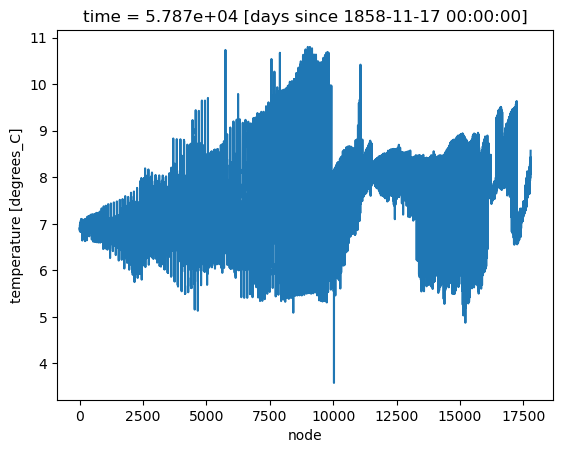

In [25]:
fvcom_temp0.plot()

In [29]:
fvcom_temp0.plot.contourf(x='lon', y='lat')

ValueError: axes don't match array

### AI GENERATED CODE. IGNORE BELOW



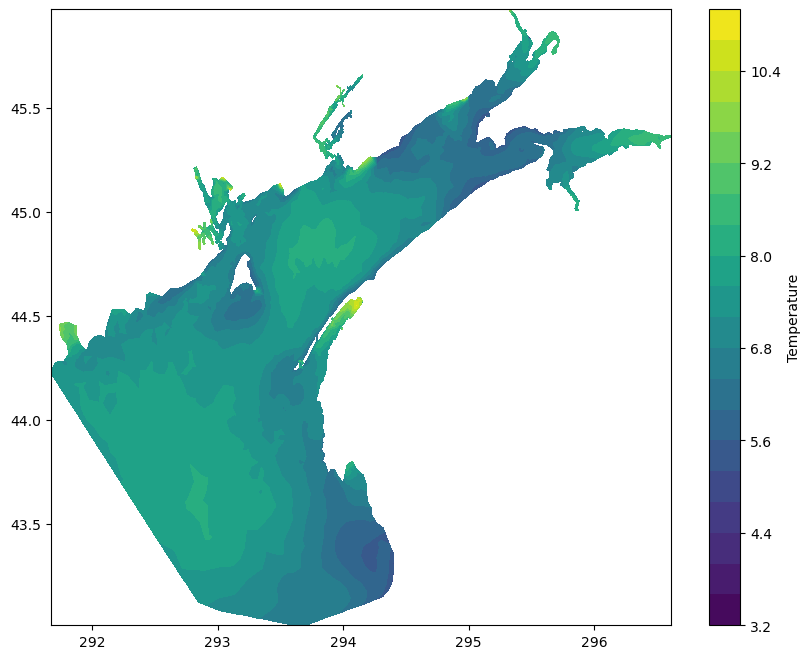

In [33]:
import matplotlib.tri as tri
ds = fvcom_ds
# FVCOM 'nv' uses 1-based Fortran indexing; convert to 0-based indexing for Python
nv = ds.nv.values - 1 if ds.nv.values.min() == 1 else ds.nv.values

# Reorient nv array if it is shape (3, nele) instead of (nele, 3)
triangles = nv.T if nv.shape[0] == 3 else nv

# Define the exact grid topology
triangulation = tri.Triangulation(lon, lat, triangles=triangles)

plt.figure(figsize=(10, 8))
plt.tricontourf(triangulation, temp, levels=20, cmap='viridis')
plt.colorbar(label='Temperature')
plt.show()

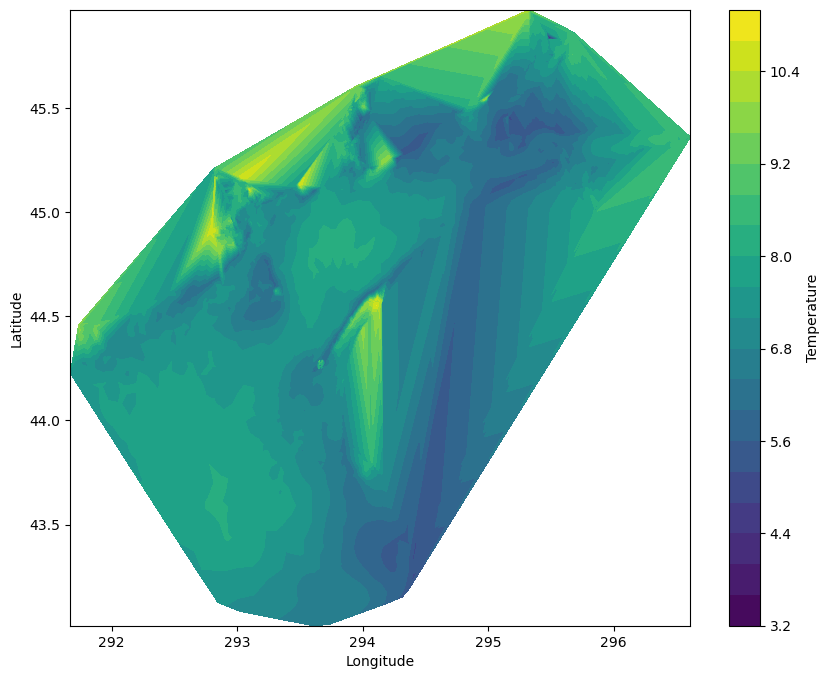

In [30]:
import matplotlib.pyplot as plt

# Extract 1D numpy arrays from your DataArray
lon = fvcom_temp0.lon.values
lat = fvcom_temp0.lat.values
temp = fvcom_temp0.values

# Plot using unstructured triangular contouring
plt.figure(figsize=(10, 8))
plt.tricontourf(lon, lat, temp, levels=20, cmap='viridis')
plt.colorbar(label='Temperature')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()